# Drosophila larval crawling analysis

Pipeline this notebook picks up from:

1. **Raspberry Pi** records each trial as an `.h264` video (3 min, 30 fps).
2. **ffmpeg** converts each video into a folder of per-frame `.png` images.
3. **The Fiji macro** (`larva_tracking.ijm`) tracks the larva in that PNG folder and saves one
   coordinates CSV per video, with columns `Frame, Time_s, X_px, Y_px, X_mm, Y_mm, Area_px, Detected`.
4. **This notebook** (using `larva_analysis.py`) cleans each CSV, computes distance/speed,
   plots trajectories, and — if you point it at a folder of many CSVs — builds one summary
   table across all your larvae with automatic QC flags.

**Before running:** make sure `larva_analysis.py` is in the same folder as this notebook
(or on your Python path), since every step below imports from it.

The cleaning logic (short-gap interpolation vs. long real gaps, and automatic outlier
rejection for false detections like debris) lives entirely in `larva_analysis.py` — see the
docstrings there for the reasoning. This notebook is just the workflow around it.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Ensure Python can find larva_analysis.py whether run from python/ or repo root
for p in [Path.cwd(), Path.cwd() / 'python', Path.cwd() / 'behavior' / 'python', Path.cwd().parent / 'python']:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

try:
    from larva_analysis import (
        load_and_clean,
        compute_kinematics,
        summarize,
        summarize_by_epoch,
        plot_trajectory,
        plot_multi_larva_overlay,
        parse_filename_metadata,
        list_flagged_events,
        batch_summarize,
    )
except ImportError:
    from behavior.python.larva_analysis import (
        load_and_clean,
        compute_kinematics,
        summarize,
        summarize_by_epoch,
        plot_trajectory,
        plot_multi_larva_overlay,
        parse_filename_metadata,
        list_flagged_events,
        batch_summarize,
    )

pd.set_option('display.max_columns', None)


ModuleNotFoundError: No module named 'numpy'

## Single-video analysis

Start here to check one video end-to-end before batch-processing everything.


In [34]:
# ---- EDIT THIS CELL for your data ----
from pathlib import Path

# Search in data/csvs first, with fallbacks to other common relative directories
search_folders = [Path('../data/csvs'), Path('data/csvs'), Path('behavior/data/csvs'), Path('.'), Path('..')]
available_csvs = []
for folder in search_folders:
    if folder.exists():
        available_csvs = [p for p in sorted(folder.glob('*.csv')) if not p.name.startswith('larva_batch_summary')]
        if available_csvs:
            break

CSV_PATH = str(available_csvs[0]) if available_csvs else 'larva_coordinates2.csv'

FPS = 30                             # frames per second of the recording
MAX_GAP_FRAMES = 5                   # gaps <= this many frames get interpolated; longer gaps are left as real breaks
MAX_SPEED_MM_S = 10.0                # velocity ceiling (mm/s) -- steps faster than this are tracking jumps, not real movement
                                     # L1 larvae crawl at ~0.5-3 mm/s; 10 mm/s is a generous physiological ceiling.
                                     # Set to None to disable velocity-based filtering.

# Optional: draw the dish edge on the trajectory plot. Leave as None to auto-detect or skip.
DISH_CENTER_MM = None   # e.g. (10.0, 10.0)
DISH_RADIUS_MM = None   # e.g. 9.5

# Optional: arena boundary filter -- detections outside the arena are wiped to NaN.
# Set to None to disable (any value > 1.0 has no effect since nothing can be that far out).
# Set to e.g. 1.0 to remove false detections strictly outside the dish edge.
# Set to e.g. 0.95 to be slightly more aggressive (5% inside the edge).
ARENA_MARGIN_FRACTION = 1.0   # None = disabled; 1.0 = remove points outside dish

print(f'Selected file for single-video analysis: {CSV_PATH}')


Ficheiro selecionado para analise individual: N2_nSybxRalRNAi_L1_FA.csv


In [35]:
df = load_and_clean(CSV_PATH, fps=FPS, max_gap_frames=MAX_GAP_FRAMES, arena_margin_fraction=ARENA_MARGIN_FRACTION)
df = compute_kinematics(df, max_speed_mm_s=MAX_SPEED_MM_S)
df.head()


,,Frame,Time_s,X_px,Y_px,X_mm,Y_mm,Area_px,Detected,Arena_center_X_px,Arena_center_Y_px,Arena_center_X_mm,Arena_center_Y_mm,Arena_radius_px,Arena_radius_mm,X_mm_clean,Y_mm_clean,is_long_gap,is_short_gap_filled,is_outlier_rejected,is_teleport_excursion,fps,noise_scale_mm,deviation_threshold_used_mm,is_outside_arena,X_centered_mm,Y_centered_mm,is_speed_outlier,step_dist_mm,speed_mm_s,cumulative_distance_mm
0,1,1,0.033,625.729,521.537,59.031,49.202,373,1,604.5,500,57.028,47.17,477.75,45.071,59.031,49.202,False,False,False,False,30,0.002483,0.3,False,2.003,-2.032,False,NaN,NaN,0.000000
1,2,2,0.067,624.785,521.394,58.942,49.188,342,1,604.5,500,57.028,47.17,477.75,45.071,58.942,49.188,False,False,False,False,30,0.002483,0.3,False,1.914,-2.018,False,0.090094,2.702832,0.090094
2,3,3,0.100,624.386,521.580,58.904,49.206,351,1,604.5,500,57.028,47.17,477.75,45.071,58.904,49.206,False,False,False,False,30,0.002483,0.3,False,1.876,-2.036,False,0.042048,1.261428,0.132142
3,4,4,0.133,624.362,521.696,58.902,49.217,348,1,604.5,500,57.028,47.17,477.75,45.071,58.902,49.217,False,False,False,False,30,0.002483,0.3,False,1.874,-2.047,False,0.011180,0.335410,0.143322
4,5,5,0.167,624.363,521.717,58.902,49.219,346,1,604.5,500,57.028,47.17,477.75,45.071,58.902,49.219,False,False,False,False,30,0.002483,0.3,False,1.874,-2.049,False,0.002000,0.060000,0.145322


### Headline numbers

`total_distance_mm` and the speed stats only use steps where both endpoints are real or
short-gap-interpolated points — a long untracked stretch never gets counted as if the larva
teleported across it. `pct_time_untracked` and `longest_untracked_stretch_s` tell you how much
of this particular video to actually trust.


In [36]:
stats = summarize(df)
for k, v in stats.items():
    print(f"{k:32s}: {v:.4f}" if isinstance(v, (int, float, np.floating)) else f"{k:32s}: {v}")


total_frames                    : 5402.0000
pct_time_untracked              : 2.6657
longest_untracked_stretch_s     : 0.0000
n_short_gaps_interpolated       : 19
n_outliers_rejected             : 163
n_speed_outliers                : 0
total_distance_mm               : 139.1072
mean_speed_mm_s                 : 0.7949
median_speed_mm_s               : 0.5909
max_speed_mm_s                  : 4.6216


### Flagged frames (possible false detections)

Automatic outlier rejection compares each point to the median position of its local window;
the frames it rejected are grouped into events below for a quick human sanity check — most
videos should show zero or a couple of short entries here.


In [37]:
list_flagged_events(df)


,start_frame,end_frame,n_frames
0,745,746,2
1,767,772,6
2,4780,4810,31
3,4860,4870,11
4,5011,5011,1
5,5016,5033,18
6,5036,5036,1
7,5042,5042,1
8,5105,5136,32
9,5138,5154,17


### Trajectory plot

Colored by time; any long untracked stretch is drawn as a gap in the line rather than a
straight-line guess, so you can see directly where and for how long tracking was lost.


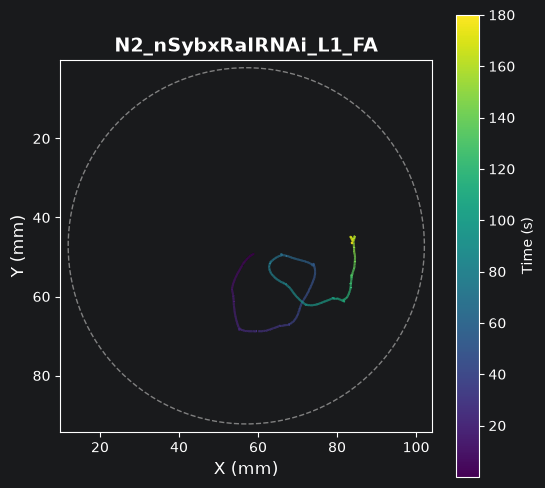

In [38]:
fig, ax = plot_trajectory(
    df,
    title=Path(CSV_PATH).stem,
    dish_center_mm=DISH_CENTER_MM,
    dish_radius_mm=DISH_RADIUS_MM,
)
plt.show()


### Speed over time (per-epoch)

A single global max speed is very sensitive to one noisy frame, so this breaks the video into
fixed-length epochs and reports max/mean/median speed per epoch — useful for seeing when the
larva was moving vs. resting.


In [39]:
EPOCH_S = 10  # seconds per epoch

epoch_stats = summarize_by_epoch(df, epoch_s=EPOCH_S)
epoch_stats


,epoch,max,mean,median
0,0,4.621558,1.186917,0.879256
1,1,4.011035,1.206812,1.052345
2,2,3.693048,1.193859,1.034456
3,3,2.798857,0.917080,0.782876
4,4,3.889602,1.189579,1.039880
5,5,3.654217,0.798910,0.618102
6,6,2.837816,0.828535,0.728075
7,7,3.587102,0.790302,0.627487
8,8,3.115670,0.979492,0.874643
9,9,3.067197,0.862987,0.720937


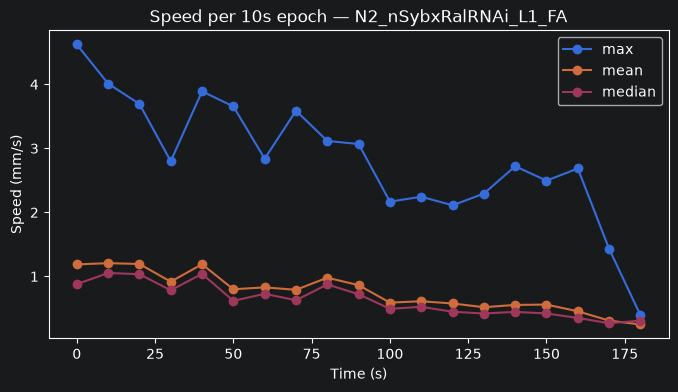

In [40]:
fig, ax = plt.subplots(figsize=(8, 4))
epoch_time_s = epoch_stats["epoch"] * EPOCH_S
ax.plot(epoch_time_s, epoch_stats["max"], label="max", marker="o")
ax.plot(epoch_time_s, epoch_stats["mean"], label="mean", marker="o")
ax.plot(epoch_time_s, epoch_stats["median"], label="median", marker="o")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (mm/s)")
ax.set_title(f"Speed per {EPOCH_S}s epoch — {Path(CSV_PATH).stem}")
ax.legend()
plt.show()


### Cumulative distance traveled

A quick check on overall activity level and whether the larva kept crawling steadily or
mostly stopped early.


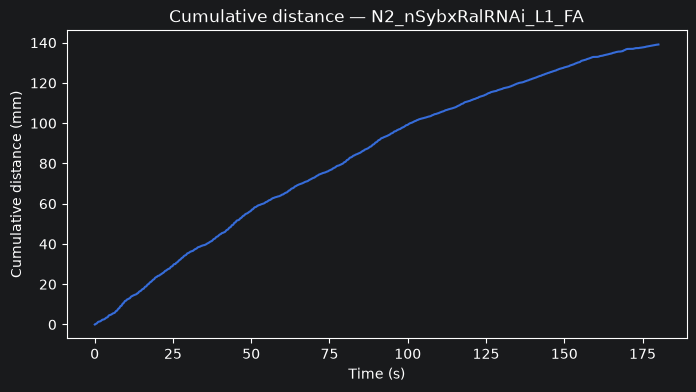

In [41]:
cum_dist = df["step_dist_mm"].fillna(0).cumsum()
t = df["Frame"] / df["fps"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, cum_dist)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Cumulative distance (mm)")
ax.set_title(f"Cumulative distance — {Path(CSV_PATH).stem}")
plt.show()


## 2. Batch analysis (many videos / larvae at once)

Point this at a folder containing all your Fiji-macro output CSVs (one per video/larva).
Each file is run through the same cleaning + kinematics pipeline, then combined into one
summary table with automatic QC flags — videos whose numbers stand out from the rest of the
batch (not from a fixed universal cutoff, since "normal" varies by genotype/condition/setup)
get flagged for a quick visual double-check.


In [42]:
# ---- EDIT THIS CELL for your data ----

# Automatically determine the directory containing coordinate CSVs
candidate_csv_folders = [Path('../data/csvs'), Path('data/csvs'), Path('behavior/data/csvs'), Path('.')]
CSV_FOLDER = '.'
for cand in candidate_csv_folders:
    if cand.exists() and any(cand.glob('*.csv')):
        CSV_FOLDER = str(cand)
        break

CSV_PATTERN = '*.csv'     # glob pattern to select them; narrow this if the folder has other CSVs

csv_paths = [
    p for p in sorted(Path(CSV_FOLDER).glob(CSV_PATTERN))
    if not p.name.startswith('larva_batch_summary')
]
print(f'Using CSV_FOLDER: {CSV_FOLDER}')
print(f'Found {len(csv_paths)} CSV files:')
for p in csv_paths:
    print(' -', p.name)


Found 7 CSV files:
 - N2_nSybxRalRNAi_L1_FA.csv
 - N2_RalG0501_L3_FA.csv
 - N3_nSybxRalRNAi_L1_FA.csv
 - N3_nSybxRalRNAi_L5_FA.csv
 - N3_W1118_L1_FA.csv
 - nSybxRalRNAiBL29580_29C_L4_FA.csv
 - w1118_L1_FA.csv


In [43]:
summary_table = batch_summarize(
    csv_paths,
    fps=FPS,
    max_gap_frames=MAX_GAP_FRAMES,
    max_speed_mm_s=MAX_SPEED_MM_S,
)
summary_table


,total_frames,pct_time_untracked,longest_untracked_stretch_s,n_short_gaps_interpolated,n_outliers_rejected,n_speed_outliers,total_distance_mm,mean_speed_mm_s,median_speed_mm_s,max_speed_mm_s,genotype,stage,condition,replicate,noise_scale_mm,n_flagged_events,flagged,flag_reason
file,,,,,,,,,,,,,,,,,,
N2_nSybxRalRNAi_L1_FA.csv,5402,2.665679,0.000000,19,163,0,139.107195,0.794898,0.590931,4.621558,N2,nSybxRalRNAi,L1,FA,0.002483,19,False,
N2_RalG0501_L3_FA.csv,5402,8.978156,0.000000,56,541,12,117.235583,0.719384,0.474342,9.916577,N2,RalG0501,L3,FA,0.020861,45,False,
N3_nSybxRalRNAi_L1_FA.csv,5402,100.000000,180.066667,0,0,0,0.000000,NaN,NaN,NaN,N3,nSybxRalRNAi,L1,FA,0.300000,0,True,high untracked %
N3_nSybxRalRNAi_L5_FA.csv,5402,66.456868,115.266667,12,0,0,60.668198,1.006663,0.752396,4.884199,N3,nSybxRalRNAi,L5,FA,0.004965,0,True,high untracked %
N3_W1118_L1_FA.csv,5403,0.000000,0.000000,0,0,0,128.480338,0.713515,0.531601,3.730147,N3,W1118,L1,FA,0.009930,0,False,
nSybxRalRNAiBL29580_29C_L4_FA.csv,5402,10.199926,5.266667,63,0,0,81.706587,0.506760,0.361248,4.103425,nSybxRalRNAiBL29580,,,29C_L4_FA,0.016896,0,False,
w1118_L1_FA.csv,5403,90.098094,88.266667,29,69,7,14.804316,0.882961,0.488365,7.379104,w1118,L1,FA,,0.031935,14,True,high untracked %


In [44]:
flagged = summary_table[summary_table["flagged"]]
print(f"{len(flagged)} of {len(summary_table)} videos flagged for a manual check:")
flagged[["flag_reason"]]


3 of 7 videos flagged for a manual check:


,flag_reason
file,
N3_nSybxRalRNAi_L1_FA.csv,high untracked %
N3_nSybxRalRNAi_L5_FA.csv,high untracked %
w1118_L1_FA.csv,high untracked %


### Comparing larvae: distance and speed

Bar chart of total distance per larva, plus a boxplot of per-frame speeds so you can see
spread as well as central tendency.


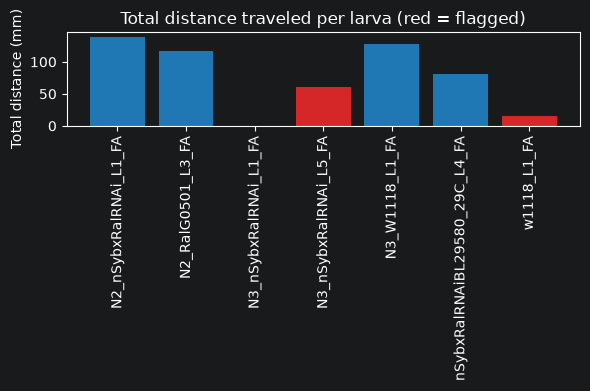

In [45]:
fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(summary_table)), 4))
labels = [Path(f).stem for f in summary_table.index]
colors = ["tab:red" if f else "tab:blue" for f in summary_table["flagged"]]
ax.bar(labels, summary_table["total_distance_mm"], color=colors)
ax.set_ylabel("Total distance (mm)")
ax.set_title("Total distance traveled per larva (red = flagged)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


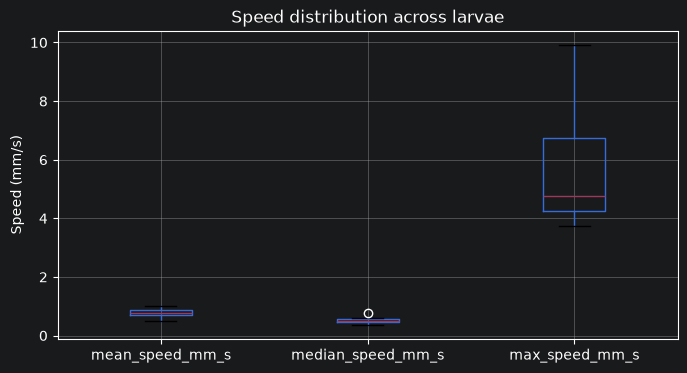

In [46]:
fig, ax = plt.subplots(figsize=(8, 4))
speed_cols = ["mean_speed_mm_s", "median_speed_mm_s", "max_speed_mm_s"]
summary_table[speed_cols].boxplot(ax=ax)
ax.set_ylabel("Speed (mm/s)")
ax.set_title("Speed distribution across larvae")
plt.show()


### Save the batch summary

Writes the full summary table (including QC flags) to a CSV and an Excel file next to this
notebook.


In [47]:
results_folder = Path('../data/results') if Path('../data/results').exists() else Path('data/results') if Path('data/results').exists() else Path('.')
summary_csv_path = results_folder / 'larva_batch_summary.csv'
summary_xlsx_path = results_folder / 'larva_batch_summary.xlsx'
summary_table.to_csv(summary_csv_path)
summary_table.to_excel(summary_xlsx_path)
print(f'Saved {summary_csv_path} and {summary_xlsx_path}')


Saved larva_batch_summary.csv and larva_batch_summary.xlsx


### Multi-Larva Trajectory Overlay (Arena-Centered)

This reproduces the multi-larva overlay plot (as in Empty_Trajectories.ipynb and Hid_all_larvae_inferno.png).
Each larva trajectory is re-centered around the arena origin (0, 0) and plotted together
with a circular arena boundary and distinct colors from the chosen colormap.


Excluindo 3 larva(s) flagged do overlay:
  N3_nSybxRalRNAi_L1_FA.csv: high untracked %
  N3_nSybxRalRNAi_L5_FA.csv: high untracked %
  w1118_L1_FA.csv: high untracked %


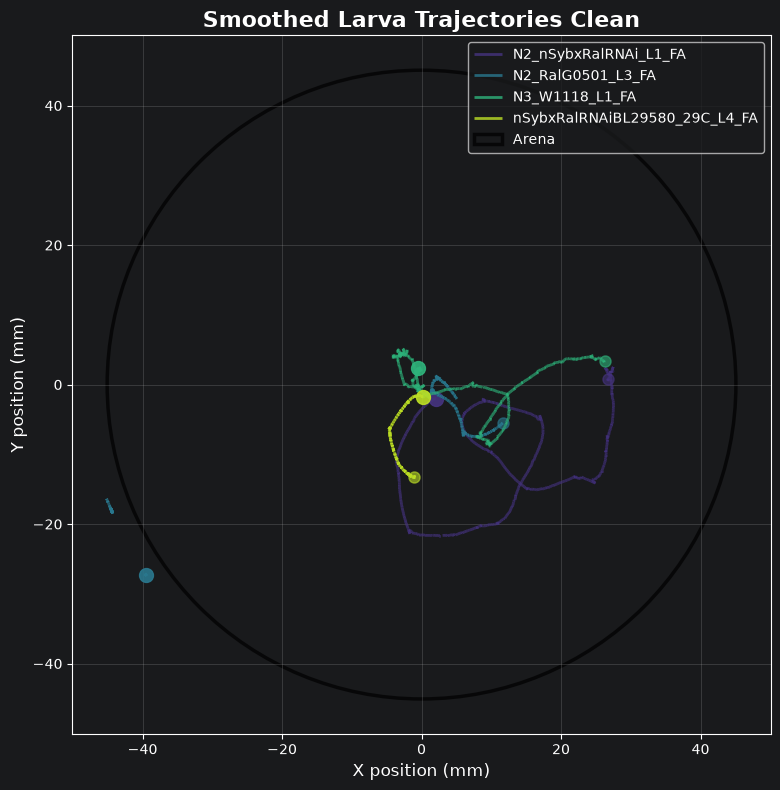

In [48]:
# Filter out larvae flagged by QC (e.g., severe tracking loss / jumps)
# summary_table includes a boolean 'flagged' column.
flagged_files = set(summary_table[summary_table['flagged']].index)
clean_paths = [p for p in csv_paths if str(p) not in flagged_files]

if flagged_files:
    print(f'Excluding {len(flagged_files)} flagged larva(e) from the overlay:')
    for f in sorted(flagged_files):
        reason = summary_table.loc[f, 'flag_reason']
        print(f'  {Path(f).name}: {reason}')
else:
    print('No flagged larvae. All files included in the overlay.')

# Load clean larvae into the overlay
all_dfs = []
larva_labels = []

for p in clean_paths:
    df_larva = load_and_clean(p, fps=FPS, max_gap_frames=MAX_GAP_FRAMES, arena_margin_fraction=ARENA_MARGIN_FRACTION)
    df_larva = compute_kinematics(df_larva, max_speed_mm_s=MAX_SPEED_MM_S)
    all_dfs.append(df_larva)
    meta = parse_filename_metadata(p)
    larva_labels.append(meta.get('stem', p.stem))

# Multi-larva arena-centered overlay plot
# Use palette_name="viridis" or "inferno"
results_folder = Path('../data/results') if Path('../data/results').exists() else Path('data/results') if Path('data/results').exists() else Path('.')
overlay_save_path = results_folder / 'all_larvae_trajectory_overlay.png'
fig, ax = plot_multi_larva_overlay(
    all_dfs,
    labels=larva_labels,
    title='Smoothed Larva Trajectories Clean',
    palette_name='viridis',
    save_path=str(overlay_save_path),
)
plt.show()


## Notes / parameters you may want to tune

- **`MAX_GAP_FRAMES`** — how many consecutive undetected frames still count as a "blip" to
  interpolate through, vs. a real loss of tracking (e.g. larva at the dish wall) that's left
  as a gap and excluded from distance/speed.
- **Outlier rejection threshold** — set automatically per video in `load_and_clean`
  (`deviation_multiplier`, `min_deviation_floor_mm`, `local_window` arguments), so a noisier
  video gets a looser threshold rather than one fixed number for every video. Override
  `max_local_deviation_mm` directly if you want the same fixed threshold everywhere instead.
- **`EPOCH_S`** — length of the time bins used for the per-epoch speed summary.
- Re-run `list_flagged_events(df)` for any individual video whose batch row got flagged, to see
  exactly which frames were rejected before deciding whether to trust it.
